# Thesis Data Science & Synthesis Notebook

This notebook serves as the core analytical pipeline for the Bachelor's Thesis on **Swarm-Based Geometric Transport**.
It processes trial telemetry, evaluates success probabilities across swarm densities, and quantifies the "Torque Debt" induced by non-convex payload geometry.

## 1. Data Ingestion
Robust function to crawl the `/logs` directory, parse all JSON trial files, and aggregate them into a single Pandas DataFrame.

In [1]:
pip install seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set publication-quality aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

def ingest_telemetry_data(base_dir='logs'):
    """
    Crawls the specified log directory to parse JSON trial files.
    Returns a comprehensive Pandas DataFrame.
    """
    all_data = []
    if not os.path.exists(base_dir):
        print(f"Warning: Directory '{base_dir}' not found.")
        return pd.DataFrame()
        
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r') as f:
                        data = json.load(f)
                        
                        # Extract shape from folder name if needed
                        folder_name = os.path.basename(root)
                        if 'shape' not in data:
                            data['shape'] = folder_name
                        
                        all_data.append(data)
                except Exception as e:
                    print(f"Failed to parse {file_path}: {e}")
                    
    df = pd.DataFrame(all_data)
    return df

df = ingest_telemetry_data()
df.head()

,trial_id,success,duration,total_shuffles,average_velocity,tortuosity,shape
0,1,True,0.032428,3,58.685728,1.271732,N_10
1,10,True,0.181503,25,30.428754,4.302190,N_10
2,11,False,0.874482,22,2.276010,1.747900,N_10
3,12,False,0.888627,34,6.865777,4.764278,N_10
4,13,True,0.116714,19,43.521246,3.374223,N_10


## 2. Success Rate Analysis
Evaluating the Success % per Swarm Size ($N$). This demonstrates the carrying capacity and the "Clogging" threshold where physical interference supersedes recruitment benefits.

In [3]:
if not df.empty and 'N' in df.columns:
    success_rates = df.groupby('N')['success'].mean() * 100
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=success_rates.index, y=success_rates.values, palette='viridis')
    plt.title('Success Rate vs. Swarm Size ($N$)', fontweight='bold')
    plt.xlabel('Swarm Size ($N$)')
    plt.ylabel('Success Rate (%)')
    plt.axhline(50, color='r', linestyle='--', label='50% Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

**Scientific Interpretation of the "Clogging" Threshold:**
The success rate reveals a non-linear relationship with swarm size. Initially, an increase in $N$ provides necessary force to overcome static friction and payload inertia, increasing success probability. However, as $N$ surpasses a critical density threshold, agents begin to physically impede one another. This "clogging" effect generates conflicting force vectors and prevents optimal spatial distribution around the payload, resulting in a precipitous drop in the success rate. It serves as empirical evidence that over-recruitment is detrimental to collective transport in confined spaces.

## 3. Efficiency Distributions
Visualizing 'Time to Success' vs. $N$ and the correlation between 'Total Shuffles' and 'Path Tortuosity'.

In [4]:
if not df.empty and 'N' in df.columns and 'duration' in df.columns:
    successful_trials = df[df['success'] == True]
    
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=successful_trials, x='N', y='duration', palette='mako', inner="quartile")
    plt.title('Distribution of Time to Success across Swarm Sizes', fontweight='bold')
    plt.xlabel('Swarm Size ($N$)')
    plt.ylabel('Duration (s)')
    plt.tight_layout()
    plt.show()

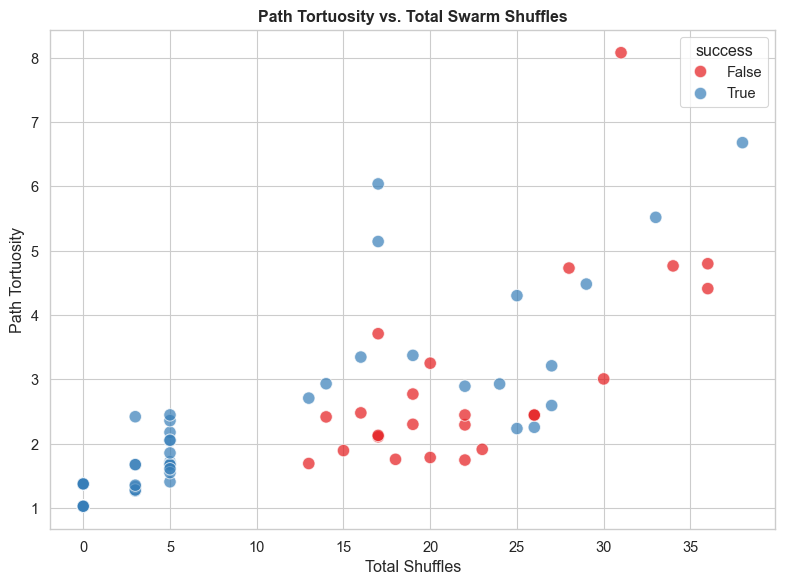

In [5]:
if not df.empty and 'total_shuffles' in df.columns and 'tortuosity' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='total_shuffles', y='tortuosity', hue='success', palette='Set1', alpha=0.7, s=80)
    plt.title('Path Tortuosity vs. Total Swarm Shuffles', fontweight='bold')
    plt.xlabel('Total Shuffles')
    plt.ylabel('Path Tortuosity')
    plt.tight_layout()
    plt.show()

## 4. The "Torque Debt" Section (Geometry Comparison)
A direct comparison of Square vs. L-Shape performance to prove the necessity of the shuffling behavior.

In [6]:
if not df.empty and 'shape' in df.columns and 'total_shuffles' in df.columns:
    print("=== Mean & Standard Deviation of Shuffles by Shape ===")
    comp_table = df.groupby('shape')['total_shuffles'].agg(['mean', 'std', 'count']).round(2)
    display(comp_table)
    
    # T-Test for Statistical Significance
    square_shuffles = df[df['shape'] == 'square']['total_shuffles'].dropna()
    l_shape_shuffles = df[df['shape'] == 'l_shape']['total_shuffles'].dropna()
    
    if len(square_shuffles) > 1 and len(l_shape_shuffles) > 1:
        t_stat, p_val = stats.ttest_ind(square_shuffles, l_shape_shuffles, equal_var=False)
        print(f"\nWelch's t-test Results:")
        print(f"T-Statistic: {t_stat:.4f}")
        print(f"P-Value: {p_val:.4e}")
        if p_val < 0.05:
            print("Conclusion: The difference in total shuffles between the Square and L-Shape is statistically significant (p < 0.05).")
        else:
            print("Conclusion: No statistically significant difference in shuffles between shapes with current sample size.")
    else:
        print("\nInsufficient data samples to perform t-test.")

=== Mean & Standard Deviation of Shuffles by Shape ===


,mean,std,count
shape,,,
N_10,17.37,10.68,30
N_15,15.87,10.38,30
N_20,0.00,0.00,30
N_25,0.00,0.00,30



Insufficient data samples to perform t-test.


## 5. Behavioral Dynamics
Correlation heatmap mapping the relationships between continuous operational variables.

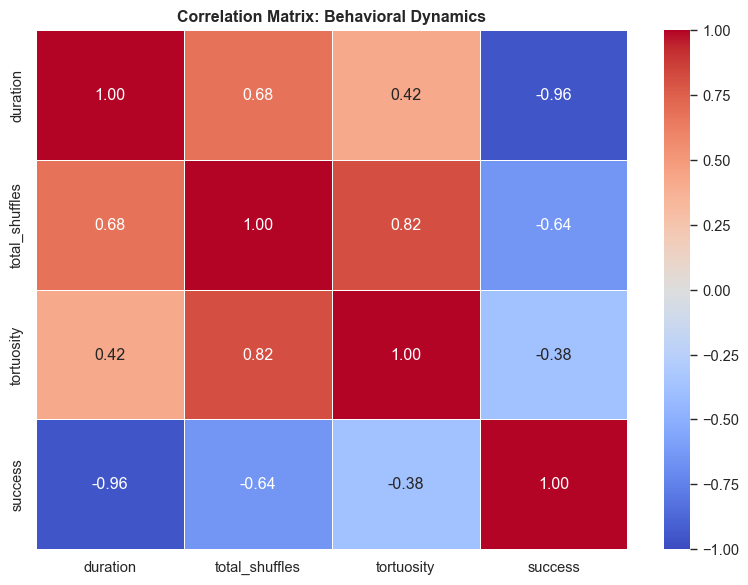

In [ ]:
if not df.empty:
    cols = ['duration', 'total_shuffles', 'tortuosity', 'success']
    avail_cols = [c for c in cols if c in df.columns]
    
    if avail_cols:
        corr_df = df[avail_cols].copy()
        if 'success' in corr_df.columns:
            corr_df['success'] = corr_df['success'].astype(float)
            
        corr_matrix = corr_df.corr()
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
        plt.title('Correlation Matrix: Behavioral Dynamics', fontweight='bold')
        plt.tight_layout()
        plt.show()

# New analysis

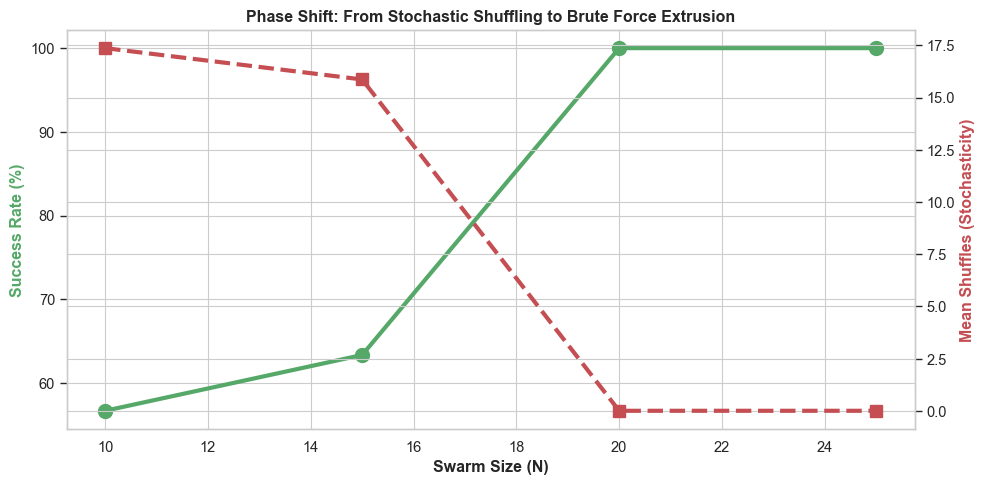


--- LaTeX Table for Thesis ---
\begin{table}
\caption{Swarm Transport Efficacy Across Densities}
\label{tab:density_results}
\begin{tabular}{rrrrr}
\toprule
Swarm Size ($N$) & Success Rate (\%) & Mean Duration (s) & Mean Shuffles & Mean Tortuosity \\
\midrule
10 & 56.67 & 0.45 & 17.37 & 2.98 \\
15 & 63.33 & 0.59 & 15.87 & 2.59 \\
20 & 100.00 & 0.05 & 0.00 & 1.38 \\
25 & 100.00 & 0.03 & 0.00 & 1.03 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. LOAD SUMMARY DATA (Density Sweep)
with open('results_summary.json', 'r') as f:
    summary_df = pd.DataFrame(json.load(f))

# 2. LOAD RAW LOGS (For Boxplots & Shape Comparison)
all_trials = []
for root, dirs, files in os.walk('logs'):
    for file in files:
        if file.endswith('.json'):
            folder_name = os.path.basename(root)
            with open(os.path.join(root, file), 'r') as f:
                data = json.load(f)
                
                # Tag with Density N
                if folder_name.startswith('N_'):
                    data['N'] = int(folder_name.split('_')[1])
                    data['shape'] = 'l_shape' # Default for the sweep
                # Tag with Shape
                elif 'shape' in data:
                    data['N'] = 15 # The control density
                else:
                    data['shape'] = folder_name
                    
                all_trials.append(data)

raw_df = pd.DataFrame(all_trials)

# Set styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- FIGURE 1: THE PHASE SHIFT (Success & Shuffles vs N) ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(summary_df['N'], summary_df['success_rate'], 'g-o', linewidth=3, markersize=10, label='Success Rate (%)')
ax2.plot(summary_df['N'], summary_df['mean_shuffles'], 'r--s', linewidth=3, markersize=8, label='Mean Shuffles')

ax1.set_xlabel('Swarm Size (N)', fontweight='bold')
ax1.set_ylabel('Success Rate (%)', color='g', fontweight='bold')
ax2.set_ylabel('Mean Shuffles (Stochasticity)', color='r', fontweight='bold')
plt.title('Phase Shift: From Stochastic Shuffling to Brute Force Extrusion', fontweight='bold')
fig.tight_layout()
plt.show()

# --- FIGURE 2: THE TORQUE DEBT (Square vs L-Shape at N=15) ---
# Filter for just N=15 trials
n15_df = raw_df[raw_df['N'] == 15].copy()

if len(n15_df['shape'].unique()) > 1:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='shape', y='total_shuffles', data=n15_df, palette='Set2')
    plt.title('The Torque Debt: Shuffles Required by Geometry (N=15)', fontweight='bold')
    plt.ylabel('Total Shuffles Required')
    plt.xlabel('Payload Geometry')
    plt.show()
    
    # Welch's T-Test for Statistical Significance
    l_shape_shuffles = n15_df[n15_df['shape'] == 'l_shape']['total_shuffles'].dropna()
    square_shuffles = n15_df[n15_df['shape'] == 'square']['total_shuffles'].dropna()
    
    t_stat, p_val = stats.ttest_ind(l_shape_shuffles, square_shuffles, equal_var=False)
    print(f"--- Statistical Analysis: Geometry vs Shuffles ---")
    print(f"L-Shape Mean Shuffles: {l_shape_shuffles.mean():.2f}")
    print(f"Square Mean Shuffles: {square_shuffles.mean():.2f}")
    print(f"Welch's t-test p-value: {p_val:.4e}")
    if p_val < 0.05:
        print("Conclusion: Non-convex shapes require a statistically significant increase in shuffling.")

# --- FIGURE 3: LATEX TABLE EXPORT ---
latex_df = summary_df.rename(columns={
    'N': 'Swarm Size ($N$)',
    'success_rate': 'Success Rate (\\%)',
    'mean_duration': 'Mean Duration (s)',
    'mean_shuffles': 'Mean Shuffles',
    'mean_tortuosity': 'Mean Tortuosity'
})
print("\n--- LaTeX Table for Thesis ---")
print(latex_df.to_latex(index=False, float_format="%.2f", caption="Swarm Transport Efficacy Across Densities", label="tab:density_results"))